# SVM + SMOTEENN

In [1]:
# Imports principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("..\\datasets_paralelos\\kmeans_7clusters.csv")

In [3]:
# 2. Separar X e y
X = df.drop(columns=['cluster'])
Y = df['cluster']

In [4]:
# 3. Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)

In [5]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=42)),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))  # multiclasse suportado automaticamente
])

In [6]:
# 5. Cross-validation
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Acurácias de cross-validation:", cv_scores)
print("Média da acurácia de cross-validation:", np.mean(cv_scores))

Acurácias de cross-validation: [0.97075869 0.97260274 0.97339305 0.97400773 0.97497366]
Média da acurácia de cross-validation: 0.9731471724622409


In [7]:
# 6. Treinar o pipeline completo no treino
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('smoteenn', SMOTEENN(random_state=42)), ('svm', SVC())])

In [8]:
# 7. Avaliar no treino
y_train_pred = pipeline.predict(X_train)
print('Métricas de Classificação para o conjunto de treino:')
print(classification_report(y_train, y_train_pred))

Métricas de Classificação para o conjunto de treino:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     12762
           1       0.97      0.98      0.98     11214
           2       0.93      1.00      0.96      4045
           3       0.97      1.00      0.99      4586
           4       0.96      0.99      0.98      6736
           5       0.94      1.00      0.97       720
           6       1.00      0.95      0.98     16877

    accuracy                           0.98     56940
   macro avg       0.97      0.99      0.98     56940
weighted avg       0.98      0.98      0.98     56940



In [9]:
# 8. Avaliar no teste
y_test_pred = pipeline.predict(X_test)
print("Métricas de Classificação para o conjunto de teste:")
print(classification_report(y_test, y_test_pred))

Métricas de Classificação para o conjunto de teste:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      5470
           1       0.97      0.98      0.97      4806
           2       0.92      0.99      0.95      1733
           3       0.97      1.00      0.98      1966
           4       0.95      0.99      0.97      2887
           5       0.96      1.00      0.98       308
           6       1.00      0.95      0.98      7233

    accuracy                           0.97     24403
   macro avg       0.96      0.98      0.97     24403
weighted avg       0.98      0.97      0.97     24403



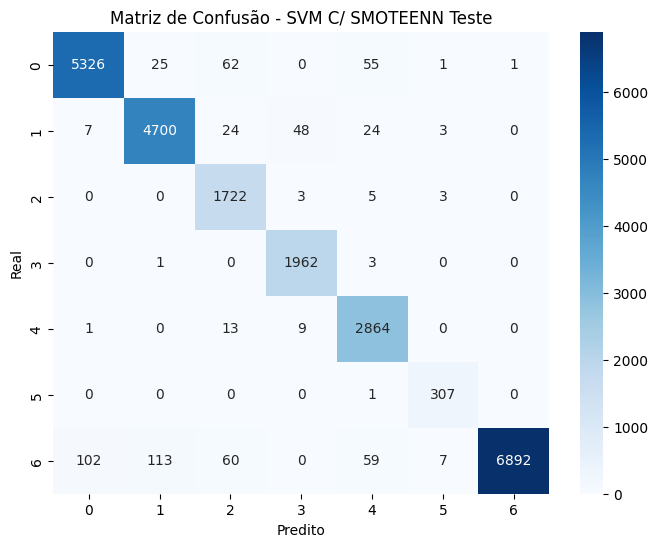

In [10]:
# 9. Matriz de confusão do teste
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(Y.unique()), yticklabels=sorted(Y.unique()))
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - SVM C/ SMOTEENN Teste')
plt.show()

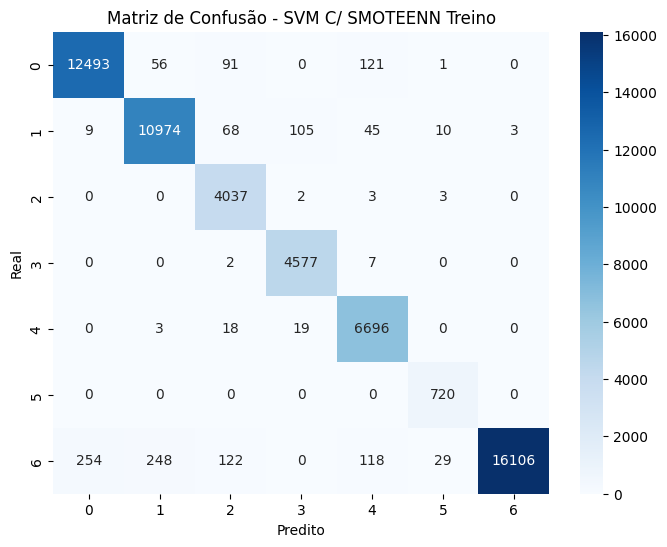

In [11]:

# Matriz de Confusão para o conjunto de treino
conf_matrix = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(Y.unique()), yticklabels=sorted(Y.unique()))
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - SVM C/ SMOTEENN Treino')
plt.show()

